In [33]:
import random
import h5py
import numpy as np
import tqdm
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d
from sklearn.preprocessing import StandardScaler
import math
import random

# User Input Desired Settings

In [34]:
# change file directory to the h5 file to convert
file = h5py.File('data2/output_digi_HDF_Mg22_Ne20pp_8MeV.h5', 'r')

# The following will be needed to run later cells to align event ids


original_keys = list(file.keys())
original_length = len(original_keys)
#print(original_keys)

In [35]:
#making an array of the lengths of events
event_lens = np.zeros(original_length, int)
for i in range(original_length):
    event = original_keys[i]
    event_lens[i] = len(file[event])

In [36]:
sample_size = 512 #enter length of number of instances per event

# x[0] ,y[1] ,z[2] ,time[3], Amplitude[4], trackID (particle ID)[5], pointID[6]
# energy[7] ,energy loss[8] ,angle[9], Mass[10], Atomic number[11], Event_id index[12], number of tracks[13]

# Enter in the CLASSIFICATION and PROJECTIONS to evaluate in all caps as projection:
# B is BINARY, T is tertiary, and FOUR is four track classiification
CLASSIFICATION = 'BINARY'
class_type = CLASSIFICATION
PROJECTION = 'XYZ'
ISOTOPE = 'Mg22'

PROJ_TO_COLS = {'XYZ': [0,1,2,5,12,13], 'XYQ': [0,1,4,5,12,13], 'XZQ': [0,2,4,5,12,13], 'YZQ': [1,2,4,5,12,13]}

user_input = PROJ_TO_COLS[PROJECTION]
print(class_type)
print(user_input)

BINARY
[0, 1, 2, 5, 12, 13]


# Convert Raw H5 File into npArray with Corresponding key index

In [37]:
#making an array of the events data-- [event #, instance, data value]
#length of each event is based on the longest event in dataset
#12th index now corresponds to index of event id in original_keys
# each instance will index according to the following 
# x,y,z, time, Amplitude, trackID (particle ID), pointID, energy, energy loss, angle, Mass, Atomic number, Event_id index
file_name = ISOTOPE + '_w_key_index'
event_data = np.zeros((original_length, np.max(event_lens), 13), float) 
for n in tqdm.tqdm(range(len(original_keys))):
    name = original_keys[n]
    event = file[name]
    ev_len = len(event)
    #converting event into an array
    for i,e in enumerate(event):
        instant = np.array(list(e))
        event_data[n][i][:12] = np.array(instant)
        event_data[n][i][-1] = float(n) #insert index value to find corresponding event ID
np.save('data2/' + file_name, event_data)

100%|██████████| 10000/10000 [05:30<00:00, 30.29it/s]


### Assertion Statements to Check the Conversion

In [38]:
data = np.load( 'data2/' + ISOTOPE + '_w_key_index' + '.npy')

assert data.shape == (original_length, np.max(event_lens), 13), 'Array has incorrect shape'
assert len(np.unique(data[:,:,12])) == original_length, 'Array has incorrect Event_ids'

# Random sample From New Numpy Array

In [39]:
#NOT completely random sampling!
#13th index now corresponds to the number of tracks in event, 0 = beam, 1= two track, 2 = 3 track...

# each instance will index according to the following 
# x,y,z, time, Amplitude, trackID (particle ID), pointID, energy, energy loss, angle, Mass, Atomic number, Event_id index, number of tracks


data_array = ISOTOPE + '_w_key_index.npy' #insert desired array to sample from 
new_array_name = ISOTOPE + '_size' + str(sample_size) + '_sampled'
data = np.load('data2/' + data_array)
new_data = np.zeros((original_length, sample_size, 14), float) 
for i in tqdm.tqdm(range(original_length)):
    ev_len = event_lens[i]    #length of event-- i.e. number of instances
    particle_ids = data[i][:ev_len,5]
    label, distr = np.unique(particle_ids, return_counts=True)
    shortest = label[np.argmin(distr)]
    shortest_ind = np.argwhere(particle_ids == shortest)
    if ev_len == sample_size:    #if array is already preferred length
        new_data[i][:,:-1] = data[i][:ev_len,:]
    else:
        instant = 0
        for n in range(shortest_ind.size):    #the first instances sampled will be those belonging to the shortest track
            new_data[i,instant,:-1] = data[i,shortest_ind[n],:]
            instant += 1
        need = sample_size - shortest_ind.size
        random_points = np.random.choice(range(ev_len), need, replace= True if need > ev_len else False)  #choosing the random instances to sample
        for r in random_points:
            new_data[i,instant,:-1] = data[i,r,:] 
            instant += 1
    unique_point_ids = np.unique(data[i,:ev_len,5])    #array of unique particle IDs
    new_data[i][0][-1] = unique_point_ids.size - 1    #number of unique particles, scaled to start at 0
np.save('data2/' + new_array_name, new_data)#creating new dataset within the h5 file for the event
    

100%|██████████| 10000/10000 [00:09<00:00, 1050.82it/s]


### Assertion Statements to Check the Data After Random Sampling

In [40]:
data = np.load( 'data2/' + ISOTOPE + '_size' + str(sample_size) + '_sampled.npy')

assert data.shape == (original_length, sample_size, 14), 'Array has incorrect shape'
assert len(np.unique(data[:,:,13])) == len(np.unique(data[:,:,5]))-1, 'Array has incorrect number of tracks'

# Check Distribution of labels after sampling

In [41]:
#cheking how the distribution of labels changes from sampling

name = ISOTOPE + '_size' + str(sample_size) + '_sampled'
data = np.load('data2/' + name + '.npy')
real_tracks = np.zeros(original_length,int) 
sampled_tracks = np.zeros(original_length,int)

for i in range(original_length):
    ev_nt = data[i]
    real_tracks[i] = ev_nt[0,-1]
    unique_point_ids = np.unique(ev_nt[:,5])    #array of unqiue particles IDs
    sampled_tracks[i] = unique_point_ids.size - 1
    
label, og_distr = np.unique(real_tracks, return_counts=True)
label, new_distr = np.unique(sampled_tracks, return_counts=True)
print(og_distr)
print(new_distr)
print('Events changed = ' + str(np.sum(np.abs(new_distr - og_distr))//2))

[5002  104 2554 2319   16    5]
[5002  105 2554 2318   16    5]
Events changed = 1


# Create npArray with 4-Track Events

In [42]:
#creating data sets with only 4-track events
file_name = ISOTOPE + '_size' + str(sample_size) + '_sampled' #insert desired file name to open
raw_data = np.load('data2/' + file_name + '.npy')
new_file_name = ISOTOPE + '_4-track_size' + str(sample_size)
count = 0
new_data = np.zeros((original_length, sample_size, 14), float)

for i in tqdm.tqdm(range(original_length)):
    event = raw_data[i]
    new_event = event[:,:]
#     new_event[:,5] -= 1 # lowering particle id to start from 0
    unique_point_ids = np.unique(new_event[:,5])    
    current_tracks = unique_point_ids.size - 1 
    og_tracks = new_event[0,-1]

    #omitting non-4-track events, mislabeled events, and that one event with a particle ID 4
    if og_tracks != 3 or og_tracks != current_tracks or 5 in unique_point_ids:
        continue
    else:
        new_event[:,5] -= 1 # lowering particle id to start from 0
        new_data[count,:,:] = new_event
        count += 1
        
print(count)
saving = new_data[:count, :,:]
np.save('data2/' + new_file_name, saving) #creating new np array

100%|██████████| 10000/10000 [00:00<00:00, 29405.73it/s]


2313


### Assertion Statements to Check the Data After Filtering Tracks 

In [43]:
data = np.load( 'data2/' + ISOTOPE + '_4-track_size' + str(sample_size)+ '.npy')
prev_data = np.load('data2/' + ISOTOPE + '_size' + str(sample_size) + '_sampled.npy')
print(list(np.unique(data[:,:,5])))

assert data.shape == (count, sample_size, 14), 'Array has incorrect shape'
assert list(np.unique(data[:,:,5])) == [0.0, 1.0, 2.0, 3.0], 'Array has incorrect particle ids'
assert len(np.unique(data[:,:,5])) == 4, 'Array has incorrect number of particle ids'
assert len(np.unique(saving[:,0,13])) == 1 , 'Array has incorrect number of tracks'
assert list(np.unique(saving[:,0,13])) == [3.0], 'Array has incorrect track'

[0.0, 1.0, 2.0, 3.0]


# Check Distribution of Labels After Filtering Tracks

In [44]:
name = ISOTOPE + '_4-track_size' + str(sample_size)
data = np.load('data2/' + name + '.npy')
real_tracks = np.zeros(len(data),int)
sampled_tracks = np.zeros(len(data),int)

for i in range(len(data)):
    ev_nt = data[i]
    real_tracks[i] = ev_nt[0,-1]
    unique_point_ids = np.unique(ev_nt[:,5])    #array of unqiue particles IDs
    sampled_tracks[i] = unique_point_ids.size - 1
    
label, og_distr = np.unique(real_tracks, return_counts=True)
label, new_distr = np.unique(sampled_tracks, return_counts=True)

# Uncomment to view:
print(len(np.unique(data[:,:,5]))) # number of tracks
print(list(np.unique(data[:,:,5]))) # Particles present in data
print(og_distr) 
print(new_distr) 
unique_point_id = np.unique(data[:,:,5])
# print((unique_point_id)) # uncomment to check particle ids
assert (np.sum(np.abs(new_distr - og_distr))//2) == 0, 'unique particle_ids and tracks do not match!'

4
[0.0, 1.0, 2.0, 3.0]
[2313]
[2313]


# Binary, Tertiary, and Other Classification

In [45]:
#a binary function, with particle 0 being the alpha
if CLASSIFICATION == 'BINARY':
    def alpha(p):
        if int(p) == 0:
            return 0
        else:
            return 1
elif CLASSIFICATION == 'TERTIARY':
    def alpha(p):
            if int(p) == 0:
                return 0
            elif int(p) == 1:
                return 1
            else:
                return 2

In [46]:
# Making the labels binary
if CLASSIFICATION == 'BINARY' or CLASSIFICATION == 'TERTIARY':
    name = ISOTOPE + '_4-track_size' + str(sample_size)
    data = np.load('data2/' + name + '.npy')
    new_classification = np.zeros((len(data), sample_size, 14), float)
    for i in tqdm.tqdm(range(len(data))):
        event = data[i]
        new_event = event[:,:]
        new_event[:,5] = list(map(alpha, event[:,5]))
        new_classification[i,:,:] = new_event[:,:]
np.save('data2/' + name, new_classification)

100%|██████████| 2313/2313 [00:00<00:00, 3544.96it/s]


# Split Testing Set, Training Set, and Validation Set

## Split Training and Testing Sets

In [47]:
# performs a 20-test 20-val 60-train split on all 4-track events
# generates an array of numbers as long as the length of the data to randomize the events 

In [48]:
name = ISOTOPE + '_4-track_size' + str(sample_size)
all_4_tracks = np.load('data2/' + name + '.npy')
rand_shuffle = np.random.choice(len(all_4_tracks), len(all_4_tracks), replace = False)


# 20-20 marking for test and validation
test_split = int(len(all_4_tracks) * .2)
val_split = int(len(all_4_tracks) * .4)


test_events =  all_4_tracks[rand_shuffle[:test_split],:,-2:]    #only saving the indices and number of tracks of the test events
val_data = all_4_tracks[rand_shuffle[test_split:val_split],:,:]
train_data = all_4_tracks[rand_shuffle[val_split:],:,:]


print(test_events.shape, val_data.shape, train_data.shape)
np.save('data2/{}_4-track_testevent_indices'.format(ISOTOPE), test_events)
np.save('data2/' + name + 'train', train_data)
np.save('data2/' + name + 'val', val_data)

(462, 512, 2) (463, 512, 14) (1388, 512, 14)


# Making Test Sets

In [49]:
#making an array of the 4-track test event lengths
name = ISOTOPE + '_4-track'
ev_indices = np.load('data2/' + name + '_testevent_indices.npy')
num_events = ev_indices.shape[0]
test_ev_lens = np.zeros(num_events,int)
for i in tqdm.tqdm(range(num_events)):
    event_ind = int(ev_indices[i,0,0])
    test_ev_lens[i] = event_lens[event_ind]
np.save('data2/' + name + 'testevent_lengths', test_ev_lens)

100%|██████████| 462/462 [00:00<00:00, 595320.57it/s]


In [50]:
#making an array of all the 4-track test data
name = ISOTOPE + '_4-track'
ev_indices = np.load('data2/' + name + '_testevent_indices.npy')
data = np.load('data2/' + ISOTOPE + '_w_key_index.npy')
num_events = ev_indices.shape[0]
test_data = np.zeros((num_events,np.max(test_ev_lens),14),float)
instant = 0
for i in tqdm.tqdm(range(num_events)):
    event_ind = int(ev_indices[i,0,0])
    test_data[instant,:,:-1] = data[event_ind,:np.max(test_ev_lens),:]
    test_data[instant,0,-1] = ev_indices[i,0,1]
    test_data[instant,:,5] -= 1   #sca;omg the labels so they start at 0
    instant += 1
np.save('data2/' + name + '_testevents', test_data)

100%|██████████| 462/462 [00:00<00:00, 17356.36it/s]


In [51]:
#making a normal sampled test dataset
name = ISOTOPE + '_4-track'
test_data = np.load('data2/' + name + '_testevents.npy')
num_events = test_data.shape[0]
test_sample = np.zeros((num_events,sample_size,14),float)
incl_points = np.zeros((num_events,sample_size),int)
for i in tqdm.tqdm(range(num_events)):
    ev_len = test_ev_lens[i]    #accessing the event index to find event length
    particle_ids = test_data[i,:ev_len,5]
    label, distr = np.unique(particle_ids, return_counts=True)
    shortest = label[np.argmin(distr)]
    shortest_ind = np.argwhere(particle_ids == shortest)
    if ev_len == sample_size:    #if array is already preferred length
        test_sample[i,:,:] = test_data[i,:ev_len,:]
        incl_points[i,:] = range(sample_size)
    else:
        instant = 0
        for n in range(shortest_ind.size):    #the first instances sampled will be those belonging to the shortest track
            test_sample[i,instant,:] = test_data[i,shortest_ind[n],:]
            incl_points[i,instant] = shortest_ind[n]
            instant += 1
        need = sample_size - shortest_ind.size
        random_points = np.random.choice(range(ev_len), need, replace= True if need > ev_len else False)  #choosing the random instances to sample
        for r in random_points:
            test_sample[i,instant,:] = test_data[i,r,:] 
            incl_points[i,instant] = r
            instant += 1
    test_sample[i,:,6] = incl_points[i,:]    #storing the indices in the original event as point IDs
    test_sample[i,:,5] = list(map(alpha, test_sample[i,:,5]))    #making it BINARY
np.save('data2/' + name + '_size{}test1'.format(sample_size), test_sample)

#array of the number of points not included in the first sample
not_incl = np.zeros(num_events, int)
for i in range(num_events):
    incl = np.unique(incl_points[i])
    not_incl[i] = event_lens[int(test_data[i,0,-2])] - incl.size
    
#indices of the points not included in the first sample
not_incl_points = np.zeros((num_events,np.max(not_incl)),int)
for i in range(num_events):    #going through each event
    count = 0
    for p in range(event_lens[int(test_data[i,0,-2])]):    #going through each instant in the event
        if p not in incl_points[i]:    #if that instant is not in the included points for that event
            not_incl_points[i, count] = p
            count += 1

100%|██████████| 462/462 [00:00<00:00, 724.13it/s]


In [52]:
#making a second test dataset that includes the points not in the first
name = ISOTOPE + '_4-track'
test_data = np.load('data2/' + name + '_testevents.npy')
num_events = test_data.shape[0]
test_sample = np.zeros((num_events,sample_size,14),float)
incl_points = np.zeros((num_events,sample_size),int)
for i in tqdm.tqdm(range(num_events)):
    ev_len = test_ev_lens[i]    #accessing the event index to find event length
    particle_ids = test_data[i,:event_lens[i],5]
    label, distr = np.unique(particle_ids, return_counts=True)
    shortest = label[np.argmin(distr)]
    shortest_ind = np.argwhere(particle_ids == shortest)
    indices_sampled = np.zeros(sample_size, int)
    if ev_len == sample_size:    #if array is already preferred length
        test_sample[i,:,:] = test_data[i,:ev_len,:]
        indices_sampled = range(sample_size)
    else:
        instant = 0
        for n in range(shortest_ind.size):    #the first instances sampled will be those belonging to the shortest track
            test_sample[i,instant,:] = test_data[i,shortest_ind[n],:]
            indices_sampled[instant] = shortest_ind[n]
            instant += 1
        for n in range(not_incl[i]):
            test_sample[i,instant,:] = test_data[i,not_incl_points[i,n],:]
            indices_sampled[instant] = not_incl_points[i,n]
            instant += 1
        random_points = np.random.choice(range(ev_len), sample_size - shortest_ind.size - not_incl[i])
        for r in random_points:
            test_sample[i,instant,:] = test_data[i,r,:]
            indices_sampled[instant] = r
            instant += 1
    test_sample[i,:,6] = indices_sampled[:]    #storing the indices in the original event as point IDs
    test_sample[i,:,5] = list(map(alpha, test_sample[i,:,5]))    #making it BINARY
np.save('data2/' + name + '_size{}test2'.format(sample_size), test_sample)

100%|██████████| 462/462 [00:00<00:00, 727.26it/s]


In [53]:
prev_data = np.load('data2/' + ISOTOPE + '_4-track_size' + str(sample_size) + '.npy')
tr = np.load('data2/' + ISOTOPE + '_4-track_size512train.npy')
va = np.load('data2/' + ISOTOPE + '_4-track_size512val.npy')
te1 = np.load('data2/'+ ISOTOPE + '_4-track_size512test1.npy')
te2 = np.load('data2/'+ ISOTOPE + '_4-track_size512test2.npy')

#works perfect if length of dataset is even, if odd, rounding may be off
# assert tr.shape == (np.ceil(len(prev_data) * .6) , sample_size, 14), 'Array has incorrect shape, check first for rounding error.'
# assert va.shape == (np.ceil(len(prev_data) * .2) , sample_size, 14), 'Array has incorrect shape, check first for rounding error.'
# assert te.shape == (np.ceil(len(prev_data) * .2) , sample_size, 14), 'Array has incorrect shape, check first for rounding error.'
print(len(prev_data))
print(tr.shape, va.shape, te1.shape, te2.shape)
print(len(np.unique(tr[:,:,5])))

2313
(1388, 512, 14) (463, 512, 14) (462, 512, 14) (462, 512, 14)
2


## Checking Test, Training, and Validation

In [54]:
check = np.load('data2/'+ ISOTOPE + '_4-track_size512train.npy')
check2 = np.load('data2/' + ISOTOPE + '_4-track_size512val.npy')
check3 = np.load('data2/'+ ISOTOPE + '_4-track_size512test1.npy')
check4 = np.load('data2/'+ ISOTOPE + '_4-track_size512test2.npy')


print(check.shape)
print(check2.shape)
print(check3.shape)
print(check4.shape)
print('')

print(check[1][0][:])
print('')

print(len(np.unique(check[:,:,12])))
print(len(np.unique(check2[:,:,12])))
print(len(np.unique(check3[:,:,12])))
print(len(np.unique(check4[:,:,12])))

(1388, 512, 14)
(463, 512, 14)
(462, 512, 14)
(462, 512, 14)

[-2.20870647e+01 -1.55518732e+01  4.01600000e+02  1.63000000e+02
  2.48577139e+02  1.00000000e+00  1.65900000e+03  6.57641966e+00
  2.42067719e-04  3.92514864e+01  2.00000000e+01  1.00000000e+01
  1.73800000e+03  3.00000000e+00]

1388
463
462
462


# Rescaling 

In [55]:
#load in test, val, and train np arrays
test1 = np.load('data2/' + ISOTOPE + '_4-track_size' + str(sample_size) + 'test1.npy')
test2 = np.load('data2/' + ISOTOPE + '_4-track_size' + str(sample_size) + 'test2.npy')
train = np.load('data2/' + ISOTOPE + '_4-track_size' + str(sample_size) + 'train.npy')
val = np.load('data2/' + ISOTOPE + '_4-track_size' + str(sample_size) + 'val.npy')

In [56]:
# assert
assert len(np.unique(np.isnan(train[:,:,4]))) == 1, 'NaNs in dataset'
assert len(np.unique(np.isnan(test1[:,:,4]))) == 1, 'NaNs in dataset'
assert len(np.unique(np.isnan(test2[:,:,4]))) == 1, 'NaNs in dataset'
assert len(np.unique(np.isnan(val[:,:,4]))) == 1, 'NaNs in dataset'
assert np.any(train[:,:,4]<0) == False, 'Dataset is incorrect, Negative charge values'
assert np.any(test1[:,:,4]<0) == False, 'Dataset is incorrect, Negative charge values'
assert np.any(test2[:,:,4]<0) == False, 'Dataset is incorrect, Negative charge values'
assert np.any(val[:,:,4]<0) == False, 'Dataset is incorrect, Negative charge values'

scaled_val_data = val
scaled_train_data = train
scaled_test_data1 = test1
scaled_test_data2 = test2
# checking shapes
print(scaled_test_data1.shape, scaled_test_data2.shape, scaled_train_data.shape, scaled_val_data.shape)

(462, 512, 14) (462, 512, 14) (1388, 512, 14) (463, 512, 14)


In [57]:
# log scale all charges to reduce large range of values
scaled_test_data1[:,:,4] = np.log10(test1[:,:,4] + 1e-10)
scaled_test_data2[:,:,4] = np.log10(test2[:,:,4] + 1e-10)
scaled_train_data[:,:,4] = np.log10(train[:,:,4] + 1e-10)
scaled_val_data[:,:,4] = np.log10(val[:,:,4] + 1e-10)

In [58]:
# values correspond to the x,y,z,charge index
values = [0,1,2,4] 

# standard scaling 
for n in values:
    mean = np.mean(scaled_train_data[:,:,n])
    std = np.std(scaled_train_data[:,:,n])
    scaled_train_data[:,:,n] = (scaled_train_data[:,:,n] - mean) / std
    scaled_test_data1[:,:,n] = (scaled_test_data1[:,:,n] - mean) / std
    scaled_test_data2[:,:,n] = (scaled_test_data2[:,:,n] - mean) / std
    scaled_val_data[:,:,n] = (scaled_val_data[:,:,n] - mean) / std
    
np.save('data2/' + ISOTOPE + '_size' + str(sample_size) + 'scaled_train_data', scaled_train_data)
np.save('data2/' + ISOTOPE + '_size' + str(sample_size) + 'scaled_test_data1', scaled_test_data1)
np.save('data2/' + ISOTOPE + '_size' + str(sample_size) + 'scaled_test_data2', scaled_test_data2)
np.save('data2/' + ISOTOPE + '_size' + str(sample_size) + 'scaled_val_data', scaled_val_data)

In [59]:
#ASSERT
train = np.load('data2/' + ISOTOPE + '_size' + str(sample_size) + 'scaled_train_data.npy')
test1 = np.load('data2/' + ISOTOPE + '_size' + str(sample_size) + 'scaled_test_data1.npy')
test2 = np.load('data2/' + ISOTOPE + '_size' + str(sample_size) + 'scaled_test_data2.npy')
val = np.load('data2/' + ISOTOPE + '_size' + str(sample_size) + 'scaled_val_data.npy')

assert np.sum(np.isnan(train)) == 0, 'NaNs in dataset'
assert np.sum(np.isnan(test1)) == 0, 'NaNs in dataset'
assert np.sum(np.isnan(test2)) == 0, 'NaNs in dataset'
assert np.sum(np.isnan(val)) == 0, 'NaNs in dataset'
assert np.sum(np.isinf(train)) == 0, 'Infinities in dataset'
assert np.sum(np.isinf(test1)) == 0, 'Infinities in dataset'
assert np.sum(np.isinf(test2)) == 0, 'Infinities in dataset'
assert np.sum(np.isinf(val)) == 0, 'Infinities in dataset'

# Get User Desired Inputs and make condensed array 
### (only using variation of x-y-z-c, particle id, event id index, num of tracks)

In [60]:
train = np.load('data2/' + ISOTOPE + '_size' + str(sample_size) + 'scaled_train_data.npy')
test1 = np.load('data2/' + ISOTOPE + '_size' + str(sample_size) + 'scaled_test_data1.npy')
test2 = np.load('data2/' + ISOTOPE + '_size' + str(sample_size) + 'scaled_test_data2.npy')
val = np.load('data2/' + ISOTOPE + '_size' + str(sample_size) + 'scaled_val_data.npy')

new_train = np.zeros((len(train), sample_size, 6), float)
new_test1 = np.zeros((len(test1), sample_size, 7), float)
new_test2 = np.zeros((len(test2), sample_size, 7), float)
new_val = np.zeros((len(val), sample_size, 6), float)


for i,index in enumerate(user_input):
    new_train[:,:,i] = train[:,:,index]
    new_test1[:,:,i] = test1[:,:,index]
    new_test2[:,:,i] = test2[:,:,index]
    new_val[:,:,i] = val[:,:,index]
    
new_test1[:,:,6] = test1[:,:,6]    #saving the POINT IDs (different from particle IDs)
new_test2[:,:,6] = test2[:,:,6]
    

np.save('data2/' + ISOTOPE + '_size' + str(sample_size) + 'train_convert' + PROJECTION, new_train)
np.save('data2/' + ISOTOPE + '_size' + str(sample_size) + 'test_convert1' + PROJECTION, new_test1)
np.save('data2/' + ISOTOPE + '_size' + str(sample_size) + 'test_convert2' + PROJECTION, new_test2)
np.save('data2/' + ISOTOPE + '_size' + str(sample_size) + 'val_convert' + PROJECTION, new_val)

In [61]:
# Checking shape after creating 
train = np.load('data2/' + ISOTOPE + '_size' + str(sample_size) + 'train_convert' + PROJECTION + '.npy')
test1 = np.load('data2/' + ISOTOPE + '_size' + str(sample_size) + 'test_convert1' + PROJECTION + '.npy')
test2 = np.load('data2/' + ISOTOPE + '_size' + str(sample_size) + 'test_convert2' + PROJECTION + '.npy')
val = np.load('data2/' + ISOTOPE + '_size' + str(sample_size) + 'val_convert' + PROJECTION + '.npy')
print(train.shape)
print(test1.shape)
print(test2.shape)
print(val.shape)
print(val[0,0])
print(train[0,0])
assert np.sum(np.isnan(train)) == 0, 'NaNs in dataset'
assert np.sum(np.isnan(test1)) == 0, 'NaNs in dataset'
assert np.sum(np.isnan(test2)) == 0, 'NaNs in dataset'
assert np.sum(np.isnan(val)) == 0, 'NaNs in dataset'
assert np.sum(np.isinf(train)) == 0, 'Infinities in dataset'
assert np.sum(np.isinf(test1)) == 0, 'Infinities in dataset'
assert np.sum(np.isinf(test2)) == 0, 'Infinities in dataset'
assert np.sum(np.isinf(val)) == 0, 'Infinities in dataset'

(1388, 512, 6)
(462, 512, 7)
(462, 512, 7)
(463, 512, 6)
[-8.79090250e-03 -7.23721249e-01 -3.30056898e-01  1.00000000e+00
  8.30800000e+03  3.00000000e+00]
[-3.47711479e-01  7.05805430e-02  9.67447125e-01  1.00000000e+00
  1.39900000e+03  3.00000000e+00]


# Make Histogram

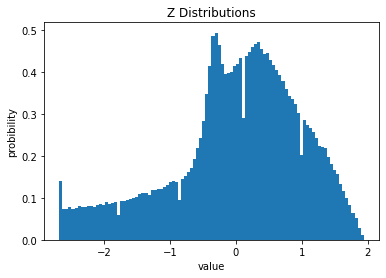

In [62]:
# Make histogram of values (either x,y,z,charge) from selected npy (train, val, test)
# Will need to change PLOT and DATA_SET_NAME to plot X-Y-Z-Q(charge) from training, val, or test
PLOT = 'Z'
DATA_SET_NAME = 'train'
index = PROJECTION.find(PLOT)

if index != -1:
    data = np.load('data2/' + ISOTOPE + '_size' + str(sample_size) + DATA_SET_NAME + '_convert' + PROJECTION + '.npy')
    info = data[:,:,index].flatten()
    plt.hist(info, density=True, bins=100)
    plt.ylabel('probibility')
    plt.xlabel('value')
    plt.title(PLOT + ' Distributions')
    plt.show()
    # plt.savefig('data2/'+ '.png', bbox_inches = 'tight') # uncomment to save
else:
    print('Value to plot is invalid, change PLOT')

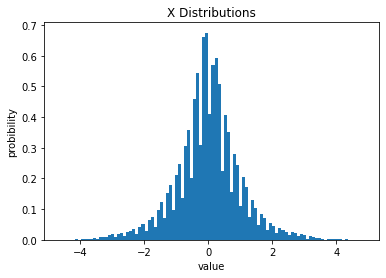

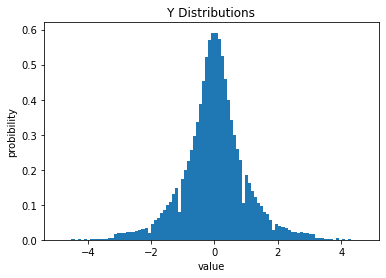

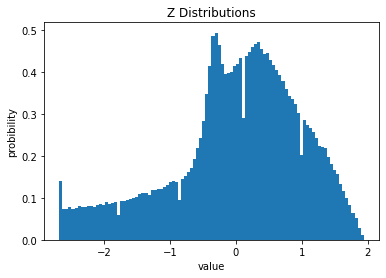

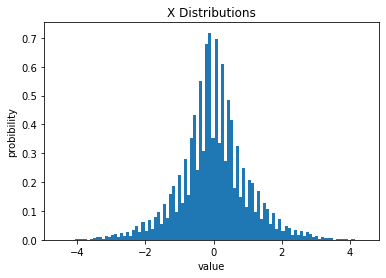

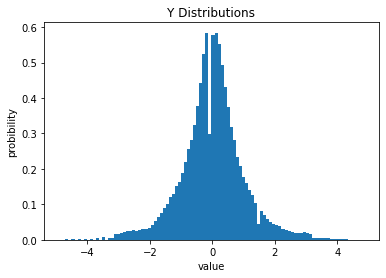

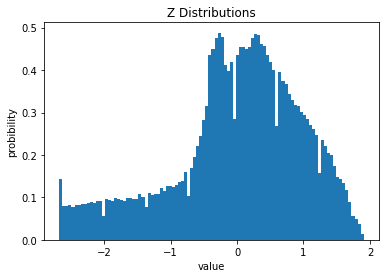

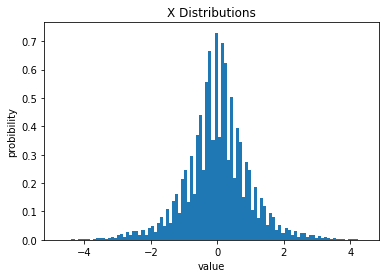

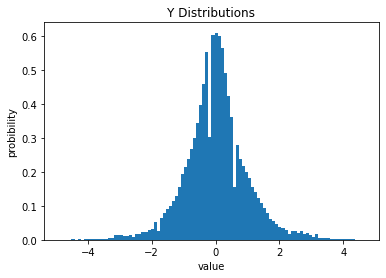

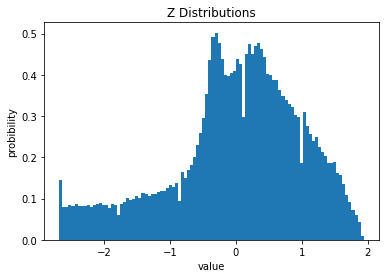

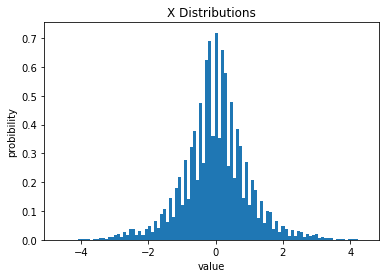

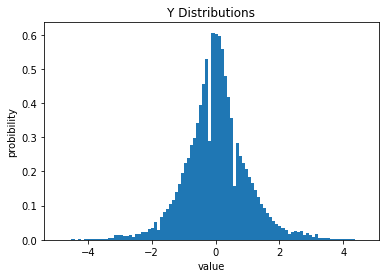

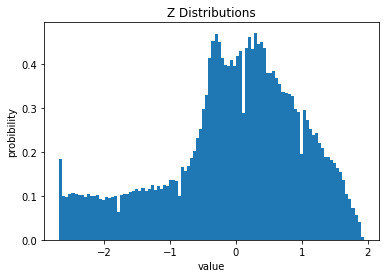

In [63]:
CLASSIFICATION = 'BINARY'
class_type = CLASSIFICATION
PROJECTION = 'XYZ'
ISOTOPE = 'Mg22'
PLOT = ['X', 'Y','Z']
DATA_SET_NAME = ['train_convert','val_convert','test_convert1','test_convert2']

for i in DATA_SET_NAME:
    for j in PLOT:
        index = PROJECTION.find(j)
        if index != -1:
            data = np.load('data2/Mg22_size512'+i+ 'XYZ.npy')
            info = data[:,:,index].flatten()
            plt.hist(info, density=True, bins=100)
            plt.ylabel('probibility')
            plt.xlabel('value')
            plt.title(j + ' Distributions')
            plt.show()
            #plt.savefig('data2/' +i+j+ '.png', bbox_inches = 'tight') 
        else:
            print('Value to plot is invalid, change PLOT')

# Convert Back to H5 File

**IMPORTANT**: All steps beyond this are now deprecated. The rest of the code below is for converting the data to the `TFRecord` format, which is no longer needed, since the training script now directly consumes numpy arrays. 

In [34]:
assert False, "Are you sure you want to continue? Comment this line out if so..."
new_h5_name = 'data2/' + ISOTOPE + '_size' + str(sample_size) + '_4-track' + class_type
file = np.load('data2/' + ISOTOPE + '_size' + str(sample_size) + 'train_convert' + PROJECTION + '.npy')
train = h5py.File(new_h5_name + '_train.h5', 'w')
for i in tqdm.tqdm(range(len(file))):
    train.create_dataset(original_keys[int(file[i,0,-2])], data = file[i])

100%|██████████| 1388/1388 [00:00<00:00, 5668.31it/s]


In [35]:
# Random checking to look at a random instance
testing = h5py.File(new_h5_name + '_train.h5', 'r')
print(len(list(testing.keys())))
key_y = list(testing.keys())
for i in range(len(key_y)):
    if np.sum(np.isinf(testing[key_y[i]])) != 0:
        continue


1388


In [36]:
new_h5_name = 'data2/' + ISOTOPE + '_size' + str(sample_size) + '_4-track' + class_type
file2 = np.load('data2/' + ISOTOPE + '_size' + str(sample_size) + 'val_convert' + PROJECTION + '.npy')
val = h5py.File(new_h5_name + '_val.h5', 'w')
for n in tqdm.tqdm(range(len(file2))):
    val.create_dataset(original_keys[int(file2[n,0,-2])], data = file2[n])

100%|██████████| 463/463 [00:00<00:00, 5130.74it/s]


In [38]:
new_h5_name = 'data2/' + ISOTOPE + '_size' + str(sample_size) + '_4-track' + class_type
file3 = np.load('data2/' + ISOTOPE + '_size' + str(sample_size) + 'test_convert1' + PROJECTION + '.npy')
test = h5py.File(new_h5_name + '_test.h5', 'w')
for n in tqdm.tqdm(range(len(file3))):
    test.create_dataset(original_keys[int(file3[n,0,-2])], data = file3[n])

  0%|          | 1/462 [00:00<00:00, 938.11it/s]


ValueError: Unable to create dataset (name already exists)

In [39]:
# Looking for bug
data = h5py.File('data2/' + ISOTOPE + '_size' + str(sample_size) + '_4-track' + class_type + '_' + 'val' + '.h5', 'r')
k = list(data.keys())
print(data[k[0]])
print(data[k[2]][0])

<HDF5 dataset "Event_[1003]": shape (512, 6), type "<f8">
[-0.68598194 -0.45222464  1.03745051  0.         39.          3.        ]


# Convert to tfrecords file

 ## Running the functions to convert h5 file to tfrecords

In [44]:
'''
This converter is used to convert hdf5 file to TFRecords.

Dataset used:
This is designed for the point cloud hdf5 data of pointnet,
which can be downloaded from https://github.com/charlesq34/pointnet/sem_seg

The sample data shape is 
    h5py {
        'data': (1000, 4096, 9), # (number_of_data, points, channels)
        'label': (1000, 4096)    # (number_of_data, label_of_points)
    }

If you want modify this for your own hdf5 data, 
the only thing you need to modify is "get_feature(point_cloud, label)" function

https://gist.github.com/shijianjian/93b52ae96137fcd3d63edd92eb3f5046
'''

import h5py
import tensorflow as tf
import numpy as np
# input_file_path = 'data2/' + ISOTOPE + '_size' + str(sample_size) + '_4-track' + class_type + '.h5'
# output_file_path = 'data2/' + ISOTOPE + '_4_track_scaled_x_y_zval.tfrecord'

assert False, "Are you sure you want to continue? Comment this line out if so..."

# For array storage, TFRecords will only support list storage or 1-D array storage
# If you have multi-dimensional array, please start with:
#     array = array.reshape(-1)
def _int64_feature(value):
    value = np.array(list(map(int, value)))
    return tf.train.Feature(int64_list=tf.train.Int64List(value=value))

def _floats_feature(value):
    value = np.reshape(value, -1)
    return tf.train.Feature(float_list=tf.train.FloatList(value=value))

def get_all_keys_from_h5(h5_file):
    res = []
    for key in h5_file.keys():
        res.append(key)
    return res

# details of 9-D vector: https://github.com/charlesq34/pointnet/issues/7
def get_feature(point_cloud):
    return {
        'points': _floats_feature(point_cloud[:, :3]),
        #'label': tf.train.Feature(int64_list=tf.train.Int64List(value=[int(point_cloud[0,12])]))    #for event classification
        'labels' : _int64_feature(point_cloud[:,3])    #for track classification
    }

# def h5_to_tfrecord_converter(input_file_path, output_file_path):
def h5_to_tfrecord_converter(input_file_path, output_file_path):
    h5_file = h5py.File(input_file_path, 'r')
    keys = get_all_keys_from_h5(h5_file)
    
    num_of_instances = h5_file[keys[0]][:].shape[0]   #in each event

    # Check the number of values in each event
    for key in keys:
        if h5_file[key][:].shape[0] != num_of_instances:
            raise ValueError('Invalid values. The inequality of the number of values in each key.')

    with tf.io.TFRecordWriter(output_file_path) as writer:
        for index in range(len(keys)):
            event = keys[index]
            example = tf.train.Example(
                features=tf.train.Features(
                    
                    feature = get_feature(h5_file[event])
              ))
            writer.write(example.SerializeToString())
            print('\r{:.1%}'.format((index+1)/num_of_instances), end='')
    

## Convert to tfrecords

### Change input path and output path to correct folders

In [45]:
DATA_SET = ['train','test','val']
for name in DATA_SET:
    input_file_path = 'data2/' + ISOTOPE + '_size' + str(sample_size) + '_4-track' + class_type + '_' + name + '.h5'
    output_file_path = 'data2/' + ISOTOPE + '_size' + str(sample_size) + '_4-track' + class_type + '_' + name + '.tfrecord'
    h5_to_tfrecord_converter(input_file_path, output_file_path)

90.4%%